# Exploration données batiments

[COLLECTE] Données date construction bâtiments
https://mattermost.services.dataforgood.fr/boards/team/4g8gayrar3r5d8ofobpk9kaxkr/bjjws538jrir4zxuh35r9kr35qo/vpki6pz3czj89fkjgth3kbq659r/cfti645hma3nbjn6woxwp7t9q9o


In [13]:
import pandas as pd
import polars as pl
import numpy as np
import geopandas as gpd
import seaborn as sns
import pyogrio
import os
import folium # For map viz
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)  # show all cols
pd.set_option("display.max_colwidth", None)  # show full width of showing cols
pd.set_option(
    "display.expand_frame_repr", False
)  # print cols side by side as it's supposed to be

**Colonnes :**

- `total_maisons` : Nombre total de maisons individuelles dans la commune.
- `total_batiments` : Nombre total de batiments dans la commune.
- `rga_[periode]_[niveau]` : Nombre de maisons par période de construction et niveau d'aléa RGA.
  - _Périodes_ : `pre1945`, `1945_1975`, `1976_2020`, `post2020`, `unk`.
  - _Niveaux_ : `nul`, `faible`, `moyen`, `fort`.
- `tri_[type]_[scenario]` : Nombre de maisons par type d'inondation et scénario de risque.
  - _Types_ : `t01` (Débordement de cours d'eau), `t02` (Submersion marine), `t03` (Ruissellement).
  - _Scénarios_ : `nul`, `faible`, `moyen`, `fort` (correspondant aux fréquences d'occurrence).


# Source 1: Données Logement INSEE


In [ ]:
bat = pd.read_csv('../csv/DS_RP_LOGEMENT_PRINC_2022_data.csv', delimiter=';')
bat.info()

In [ ]:
bat_bdx = bat[
    (bat.GEO == '13055') &
    # (bat.GEO_OBJECT == 'COM') &
    (bat.TIME_PERIOD == 2022)]

In [ ]:
bat_bdx.GEO_OBJECT.unique()

In [ ]:
bat_bdx = bat[
    (bat.GEO == '33063') &
    (bat.GEO_OBJECT == 'COM') &
    (bat.TIME_PERIOD == 2022)]

bat_bdx.head()

In [ ]:
bat_bdx[~(bat_bdx.BUILD_END == '_T')]

In [ ]:
bat.head()

In [ ]:
bat_com = bat[
    ~(bat.BUILD_END == '_T') &      # On ignore les totaux qui donnent des découpages selon d'autres axes d'analyses
    ~(bat.TDW == '_T') &            # Type de logement (On ignore le total pour ne pas compter deux fois) 
    (bat.GEO_OBJECT == 'COM') &     # On ne garde que les communes (attention pour les PLM)
    (bat.TIME_PERIOD == 2022)     # Pour l'instant on ne garde que la denière année (2022)
] 
bat_com.info()

In [ ]:
del bat #save memory

In [ ]:
bat_com_agg = bat_com[['GEO', 'BUILD_END','OBS_VALUE']].groupby(['GEO', 'BUILD_END']).sum('OBS_VALUE').reset_index()
bat_com_agg = bat_com_agg.pivot_table(index='GEO', columns=['BUILD_END'], values='OBS_VALUE').reset_index()
year_col = [col for col in bat_com_agg.columns.values if col.startswith('Y')]
bat_com_agg['Total'] = bat_com_agg[year_col].sum(axis=1)
bat_com_agg.head()

In [ ]:
bat_com_agg.head()

In [ ]:
bat_com_agg[bat_com_agg.GEO == '33063']

# Source 2: Données Inondations (Géorisques)


Fichier par département pour les zones TRI Territoire à Risque d'Inondation de GeoRisques (2020): https://www.data.gouv.fr/datasets/territoire-a-risque-dinondation-tri-du-sig-directive-inondation-france-metropolitaine-rapportage-2020-241

Fichier au format Shapefile

Layers:

- national_flood_extents : Les polygones des zones inondables par niveau de risque
- national_water_heights : Les classes de hauteurs d'eau.
- national_assets : Les enjeux (bâtiments, infrastructures).
- national_tri_communes : Les périmètres des communes des TRI. (Une ligne par commune+TRI qui la concerne)

Pour lire un layer spécifique:
`gpd.read_file("path_to.gpkg", layer="layer_name")`

Type Inondations:

- 01: Débordements de cours d’eau
- 02: Ruissellement : scénarios moyen et extrême seulement
- 03: Submersion marine
- 04: Remontées de nappes (débordements des eaux souterraines) : scénario extrême seulement


In [2]:
# Config variables
# TRI_FRANCE_FILE = "../csv_large/national_tri_2020.gpkg" # Original crazy detailed 15Gb file
TRI_FRANCE_FILE = "../csv_large/national_tri_2020_optimized.gpkg" # Only 600MB thanks to geometry simplication to 5 meters
PYOGRIO_USE_ARROW=1 #Faster read/write

In [ ]:
# Script to download, extract and convert shapefiles to optimized GPKG
import requests
import zipfile
import tempfile
import shutil
import glob
from pathlib import Path
from typing import List, Optional
import pyogrio
import importlib.util
from shapely.geometry import MultiPolygon, Polygon

def is_package_installed(name):
    return importlib.util.find_spec(name) is not None

HAS_PYOGRIO = is_package_installed("pyogrio")

# --- Configuration ---
BASE_URL = "https://files.georisques.fr/di_2020/tri_2020_sig_di_{dep}.zip"
OUTPUT_DIR = Path("../csv_large/")
OUTPUT_GPKG = OUTPUT_DIR / "national_tri_2020_optimized.gpkg"
TARGET_CRS = "EPSG:4326"  # WGS 84 - Standard for National/Global data
SIMPLIFY_TOLERANCE = 0.00005  # Approx 5m in WGS84 for optimal PoC performance

# List of departments: 01 to 95, 2A, 2B, and DOM-TOM (971-976)
DEPARTMENTS = [f"{i:02d}" for i in range(1, 96)] + ["2A", "2B"] # We don't have DROM data

# Layers mapping (prefixes to layer names in GPKG)
LAYER_CONFIG = {
    "inondable": "national_flood_extents",
    "commune": "national_tri_communes" 
}

def download_and_process(dep: str):
    """Downloads zip, extracts shp, and appends to national GPKG."""
    url = BASE_URL.format(dep=dep)
    print(f"--- Processing Department {dep} ---")
    
    try:
        response = requests.get(url, stream=True, timeout=30)
        if response.status_code != 200:
            print(f"Skipping {dep}: HTTP {response.status_code}")
            return

        with tempfile.TemporaryDirectory() as tmp_dir:
            zip_path = Path(tmp_dir) / f"{dep}.zip"
            with open(zip_path, "wb") as f:
                for chunk in response.iter_content(chunk_size=8192):
                    f.write(chunk)

            # Extract
            with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                zip_ref.extractall(tmp_dir)

            # Find and aggregate shapefiles
            for prefix, layer_name in LAYER_CONFIG.items():
                pattern = f"**/*{prefix}*s_*.shp" # Looking for surface shapefiles mainly
                shp_files = glob.glob(os.path.join(tmp_dir, pattern), recursive=True)
                
                # If no surface, try all shp for that prefix
                if not shp_files:
                    pattern = f"**/*{prefix}*.shp"
                    shp_files = glob.glob(os.path.join(tmp_dir, pattern), recursive=True)

                for shp in shp_files:
                    try:
                        gdf = gpd.read_file(shp)
                        if gdf.empty:
                            continue

                        # Standardize Projection
                        if gdf.crs is None:
                            gdf.set_crs(TARGET_CRS, inplace=True)
                        elif gdf.crs != TARGET_CRS:
                            gdf = gdf.to_crs(TARGET_CRS)

                        # Optimization: Simplify geometries to reduce file size
                        # preserve_topology=True keeps the geometry valid
                        gdf.geometry = gdf.geometry.simplify(SIMPLIFY_TOLERANCE, preserve_topology=True)

                        # Add metadata (Department code on all items)
                        gdf['dep_code'] = dep
                        gdf['source_file'] = os.path.basename(shp)
                        
                        # --- Robust Risk Classification ---
                        # 1. First, check internal 'scenario' attribute (Standardized COVADIS codes 01 to 04)
                        scen_code = str(gdf['scenario'].iloc[0]).lower() if 'scenario' in gdf.columns else ""
                        
                        # 2. Extract from filename if internal is missing or generic
                        basename = os.path.basename(shp).lower()

                        if any(x in scen_code for x in ['01mcc', '01for']) or '01for' in basename or '_01_' in basename:
                            gdf['scenario_val'] = '01For'
                        elif any(x in scen_code for x in ['02mcc', '02moy']) or '02moy' in basename or '_02_' in basename:
                            gdf['scenario_val'] = '02Moy'
                        elif any(x in scen_code for x in ['04fai', '03mcc', '04mcc']) or '04fai' in basename or '_04_' in basename or '_03_' in basename:
                            gdf['scenario_val'] = '04Fai'
                        else:
                            gdf['scenario_val'] = 'Unknown'

                        # Ensure all geometries are MULTIPOLYGON to avoid warnings and spec issues
                        gdf.geometry = gdf.geometry.apply(lambda x: MultiPolygon([x]) if isinstance(x, Polygon) else x)

                        # DROP GEOMETRY for communes to create a flat reference table
                        if layer_name == "national_tri_communes":
                            gdf = pd.DataFrame(gdf.drop(columns='geometry'))

                        # Force identifier columns to string to avoid schema conflicts
                        for col in ['id', 'id_tri', 'code']:
                            if col in gdf.columns:
                                gdf[col] = gdf[col].astype(str)

                        # Writing to GPKG (Atomic append)
                        # We use 'pyogrio' if available for speed, otherwise fiona
                        engine = 'pyogrio' if HAS_PYOGRIO else 'fiona'
                        
                        mode = 'a' if OUTPUT_GPKG.exists() else 'w'
                        
                        pyogrio.write_dataframe(
                            gdf,
                            OUTPUT_GPKG,
                            layer=layer_name,
                            driver="GPKG",
                            append=OUTPUT_GPKG.exists()
                        )
                        print(f"  Added {os.path.basename(shp)} to layer {layer_name}")

                    except Exception as e:
                        print(f"  Error processing {shp}: {e}")

    except Exception as e:
        print(f"Failed to process department {dep}: {e}")

In [85]:
# Run the extraction + cleanup
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
if OUTPUT_GPKG.exists():
    print(f"Warning: {OUTPUT_GPKG} already exists. Appending to it.")

for dep in DEPARTMENTS:
    download_and_process(dep)

NameError: name 'OUTPUT_DIR' is not defined

In [20]:
# Liste les couches et leurs types de géométrie
layers = pyogrio.list_layers(TRI_FRANCE_FILE)
print(layers)
# Obtient les informations détaillées (colonnes, types) d'une couche précise
info = pyogrio.read_info(TRI_FRANCE_FILE, layer="national_tri_communes")
print(info['fields'])
info2 = pyogrio.read_info(TRI_FRANCE_FILE, layer="national_flood_extents")
print(info['fields'])

[['national_flood_extents' 'MultiPolygon']
 ['national_tri_communes' None]]
['annee_cog' 'code_insee' 'nom_si_ext' 'hab_saison' 'nom_com' 'ver_si_ext'
 'id_si_ext' 'tx_hab_sai' 'hab_perm' 'datentree' 'datsortie' 'id_tri' 'id'
 'dep_code' 'source_file' 'scenario_val']
['annee_cog' 'code_insee' 'nom_si_ext' 'hab_saison' 'nom_com' 'ver_si_ext'
 'id_si_ext' 'tx_hab_sai' 'hab_perm' 'datentree' 'datsortie' 'id_tri' 'id'
 'dep_code' 'source_file' 'scenario_val']


In [ ]:
# Charge les données
# com = gpd.read_file("../csv_large/national_tri_2020_optimized.gpkg", layer="national_tri_communes")#, rows=100)

flood_06 = gpd.read_file(TRI_FRANCE_FILE, layer="national_flood_extents", where="dep_code = '06'", columns=['typ_inond2'])
# flood = gpd.read_file(TRI_FRANCE_FILE, layer="national_flood_extents", columns=['typ_inond2'])

# flood = gpd.read_file("../csv_large/national_tri_2020.gpkg", layer="national_flood_extents")

In [5]:
del flood

In [33]:
flood.head()

,typ_inond2,geometry
0,NaN,"MULTIPOLYGON (((4.87949 46.33083, 4.87947 46.33077, 4.87936 46.33081, 4.8794 46.33085, 4.87949 46.33083)))"
1,NaN,"MULTIPOLYGON (((4.87608 46.27473, 4.87591 46.27456, 4.87545 46.27492, 4.87648 46.27464, 4.87608 46.27473)))"
2,NaN,"MULTIPOLYGON (((4.87624 46.27406, 4.87623 46.2738, 4.87593 46.27385, 4.87593 46.27408, 4.87624 46.27406)))"
3,NaN,"MULTIPOLYGON (((4.88408 46.26301, 4.88429 46.26289, 4.88403 46.26294, 4.88408 46.26301)))"
4,NaN,"MULTIPOLYGON (((4.83893 46.31494, 4.83877 46.31483, 4.83872 46.31499, 4.83878 46.31509, 4.83893 46.31494)))"


In [34]:
flood.explore(columns='type_inond2')

: 

: 

# Source 3: Base bâtiments BNDB


Description des tables ici: https://bdnb.io/schema/latest/bdnb_v07/index.html

- **batiment_groupe**: Groupes de bâtiments au sens de la BDNB.

Un groupe de bâtiments est composé de 1 à n bâtiments fonciers et de 1 à m bâtiments constructions.
Ces entités sont créées pour minimiser n et m, afin de produire des groupes aussi précis que possible, tout en garantissant une adéquation entre : - le contenant : enceintes physiques des bâtiments (batiment_construction), - et le contenu : bâtiments fonciers qui documentent usages, surfaces et nombre de locaux.

Un groupe de bâtiments est toujours situé sur une même unité foncière (ensemble de parcelles adjacentes appartenant à un même propriétaire).

Cette entité, qui assure la cohérence entre contenant et contenu, constitue le socle de la BDNB.
La majorité des informations présentes dans la base sont définies à cette échelle : batiment_groupe.

- **batiment_groupe_risques** = Table regroupant différents indicateurs de risques (sismique, incendie, radon et argile) associés aux batiment_groupe de la BDNB. Les aléas sismiques, radon et argiles proviennent des zonages issus du site georisques. Les catégories de familles incendies proviennent d’une prédiction simplifiée de la réglementation risque incendie (sur le résidentiel uniquement). Enfin, les catégories de bâtiments associées au risque sismique correspondent à des travaux similaires au risque incendie (sur le résidentiel uniquement).

- **batiment_groupe_ffo_bat**: Données issues du traitement des fichiers fonciers pour ce bâtiment.

Caractéristiques : - Les quantitatifs (nombre de locaux, surfaces) sont calculés comme la somme des locaux et de leurs surfaces sur l’ensemble des bâtiments fonciers idbat constitutifs du groupe de bâtiments de la BDNB. - Les données d’usages sont une synthèse des différents usages identifiés dans les fichiers fonciers.

- **batiment_groupe_synthese_propriete_usage**: Table de synthèse des informations de propriété et d’usage des bâtiments.

Sources : Cette table consolide les données issues de multiples sources : - RPLS - Fichiers fonciers - Registre des copropriétés - ESPACE (projet de géolocalisation des établissements publics en partenariat avec le CEREMA) - Fichier locaux des personnes morales de la DGFiP - SIRENE

Objectif : Fournir les informations principales sur la propriété et l’usage des groupes de bâtiments.

NB : Cette table introduit le nouvel indicateur usage_principal_bdnb_open, qui remplace l’ancienne variable usage_niveau_1_txt issue des seuls fichiers fonciers.
Il est recommandé d’utiliser usage_principal_bdnb_open à la place de la donnée foncière brute.


In [109]:
import requests
r = requests.get(f'https://api.bdnb.io/v1/bdnb/donnees/batiment_groupe_risques',
                 params={   
                         'select': 'batiment_groupe_id, code_departement_insee, alea_argile, classe_famille_incendie_residentiel',
                         'batiment_groupe_id': 'eq.bdnb-bg-GWH9-79G1-B81G',
                        #  'code_departement_insee': '33',
                         'limit': 5}                 
                 )
r.json()

{'code': '42703',
 'details': None,
 'hint': None,
 'message': 'column batiment_groupe_risques.classe_famille_incendie_residentiel does not exist'}

In [110]:
import requests
r = requests.get('https://api.bdnb.io/v1/bdnb/geocodage?',
             params={'q': '57 rue Reinette Bordeaux'})
r.json()

{'type': 'FeatureCollection',
 'version': 'draft',
 'features': [{'type': 'Feature',
   'geometry': {'type': 'Point', 'coordinates': [-0.539225, 44.85035]},
   'properties': {'label': '57 Rue Reinette 33100 Bordeaux',
    'score': 0.9799681818181818,
    'housenumber': '57',
    'id': '33063_7850_00057',
    'name': '57 Rue Reinette',
    'postcode': '33100',
    'citycode': '33063',
    'x': 420459.91,
    'y': 6423063.53,
    'city': 'Bordeaux',
    'context': '33, Gironde, Nouvelle-Aquitaine',
    'type': 'housenumber',
    'importance': 0.77965,
    'street': 'Rue Reinette'}},
  {'type': 'Feature',
   'geometry': {'type': 'Point', 'coordinates': [-0.53859, 44.849853]},
   'properties': {'label': 'Impasse de la Reinette 33100 Bordeaux',
    'score': 0.48062103896103886,
    'id': '33063_7855',
    'name': 'Impasse de la Reinette',
    'postcode': '33100',
    'citycode': '33063',
    'x': 420507.56,
    'y': 6423006.13,
    'city': 'Bordeaux',
    'context': '33, Gironde, Nouvelle-A

In [111]:
import requests
r = requests.get(f'https://api.bdnb.io/v1/bdnb/donnees/batiment_groupe_complet/adresse',
                     params={'limit': 5,  # limite le nombre de réponses à 5 résultats
                             'cle_interop_adr': 'eq.33063_7850_00057'})

r.json()

[{'alea_argile': 'Moyen',
  'alea_argiles': 'Moyen',
  'altitude_sol_mean': 3,
  'annee_construction': 1898,
  'annee_construction_dpe': None,
  'arrete_2021': None,
  'batiment_groupe_id': 'bdnb-bg-EKHK-QSZT-7MC2',
  'chauffage_solaire': None,
  'classe_bilan_dpe': None,
  'classe_conso_energie_arrete_2012': None,
  'classe_conso_energie_dpe_tertiaire': None,
  'classe_inertie': None,
  'cle_interop_adr': '33063_7850_00057',
  'cle_interop_adr_principale_ban': '33063_7850_00057',
  'code_commune_insee': '33063',
  'code_departement_insee': '33',
  'code_epci_insee': '243300316',
  'code_iris': '330630403',
  'code_region_insee': '75',
  'commune_parente': '33063',
  'conso_3_usages_ep_m2_arrete_2012': None,
  'conso_5_usages_ep_m2': None,
  'conso_pro_dle_elec_2020': None,
  'conso_pro_dle_gaz_2020': None,
  'conso_res_dle_elec_2020': None,
  'conso_res_dle_gaz_2020': None,
  'contient_fictive_geom_groupe': False,
  'contrainte_urbanisme_ac1': None,
  'croisement_geospx_reussi': True,

# RGA | Residential Houses for France Metro only with BNDB


Approach 2: Local CSV (works)

We can use the BDNB dumps by département (PoC) or France entière that can be found here: https://bdnb.io/download/

Note: Because the file is huge (35Gb compressed) we leverage polars for data manipulation vs pandas


In [16]:
import pandas as pd
import geopandas as gpd
from pathlib import Path

ARCHIVE_PATH = Path("../csv_large/open_data_millesime_2025-07-a_france_csv.tar.gz")
TRI_GPKG = Path("../csv_large/national_tri_2020_optimized.gpkg")
OUTPUT_FILE_CLEAN = Path("../csv_large/france_houses_clean.parquet")
OUTPUT_FILE_AGG = Path("../csv/rga_houses_flat.parquet")

In [19]:
df = pd.read_parquet(OUTPUT_FILE_AGG)
df.head()

,code_commune_insee,total_maisons,rga_1976_2020_faible,rga_post2020_nul,rga_pre1945_moyen,rga_1945_1975_faible,rga_pre1945_faible,rga_pre1945_nul,rga_1976_2020_fort,rga_1945_1975_moyen,...,rga_1945_1975_fort,rga_1976_2020_moyen,rga_post2020_moyen,rga_post2020_fort,rga_unk_moyen,rga_unk_faible,rga_unk_fort,rga_unk_nul,nb_maisons_exposition_rga,pct_exposition_rga
0,01001,358,184,1,7,21,123,0,0,0,...,0,2,1,0,0,0,0,0,357,0.997207
1,01002,168,2,1,118,1,5,0,0,12,...,0,25,1,0,0,0,0,0,164,0.976190
2,01004,3254,930,13,458,337,392,6,0,165,...,0,869,36,0,4,2,0,0,3223,0.990473
3,01005,616,328,11,0,82,121,2,0,0,...,0,0,0,0,0,0,0,0,601,0.975649
4,01006,62,13,0,0,5,44,0,0,0,...,0,0,0,0,0,0,0,0,62,1.000000


In [21]:
df.columns

Index(['code_commune_insee', 'total_maisons', 'rga_1976_2020_faible',
       'rga_post2020_nul', 'rga_pre1945_moyen', 'rga_1945_1975_faible',
       'rga_pre1945_faible', 'rga_pre1945_nul', 'rga_1976_2020_fort',
       'rga_1945_1975_moyen', 'rga_1945_1975_nul', 'rga_1976_2020_nul',
       'rga_pre1945_fort', 'rga_post2020_faible', 'rga_1945_1975_fort',
       'rga_1976_2020_moyen', 'rga_post2020_moyen', 'rga_post2020_fort',
       'rga_unk_moyen', 'rga_unk_faible', 'rga_unk_fort', 'rga_unk_nul',
       'nb_maisons_exposition_rga', 'pct_exposition_rga'],
      dtype='str')

In [ ]:
gdf = gpd.GeoDataFrame(df, geometry=gpd.GeoSeries.from_wkb(df["geometry"]), crs="EPSG:4326")
gdf.explore()

In [121]:
df[df.alea_argile.isin(['Moyen','Fort'])].count()

batiment_groupe_id        10019881
code_departement_insee    10019881
code_commune_insee        10019881
alea_argile               10019881
periode_construction      10019881
scenario_inondation       10019881
type_inondation           10019881
dtype: int64

# Inondations | France & DROM for All Batiments with BDTOPO


In [29]:
import fiona
import pandas as pd
import geopandas as gpd 

#Test file 
# GPKG_FILE = '../csv_large/batiment.gpkg'
# Voir les couches disponibles
# layers = fiona.listlayers(GPKG_FILE)
# print(layers) # ['batiments']

### Scripts to run
# Step 1: Extracts all the 50M batiments, computes centroids and perform sjoin to get the commune insee code
# uv run tri_step1_extract_bdtopo_buildings.py # !WARNING! Takes ~10 hours
# Outputs france_all_bats_clean.parquet

### Step 2: Fetches the departement, performs sjoin with TRI zones and aggregate results by commune, nature and usage_1
# uv run tri_step2_aggregate_with_tri.py # Takes ~30 min: 
# Outputs tri_all_bats_flat.parquet


In [22]:
import pandas as pd
df_tri = pd.read_csv('../csv/tri_all_bats_flat.csv')
df_tri.columns


/var/folders/wb/bg23zgwj389404sv03x64x2m0000gn/T/ipykernel_16815/3872229120.py:2: DtypeWarning: Columns (0: code_commune_insee) have mixed types. Specify dtype option on import or set low_memory=False.
  df_tri = pd.read_csv('../csv/tri_all_bats_flat.csv')


Index(['code_commune_insee', 'agri_nul', 'resid_nul', 'autres_nul',
       'rervice_nul', 'autres_faible', 'agri_faible', 'indus_nul',
       'autres_fort', 'resid_moyen', 'rervice_fort', 'indus_moyen',
       'rervice_moyen', 'autres_moyen', 'rervice_faible', 'resid_fort',
       'agri_fort', 'resid_faible', 'agri_moyen', 'indus_faible', 'indus_fort',
       'nb_bats_total', 'nb_bats_exposition_tri', 'pct_exposition_tri'],
      dtype='str')

In [20]:
df_tri.describe()

,rervice_nul,indus_nul,resid_faible,agri_nul,resid_nul,agri_moyen,autres_nul,rervice_faible,agri_fort,rervice_fort,autres_fort,indus_faible,rervice_moyen,autres_faible,resid_moyen,autres_moyen,indus_moyen,agri_faible,resid_fort,indus_fort,nb_bats_total,nb_bats_exposition_tri,pct_exposition_tri
count,34875.000000,34875.000000,34875.000000,34875.000000,34875.000000,34875.000000,34875.000000,34875.000000,34875.000000,34875.000000,34875.000000,34875.000000,34875.000000,34875.000000,34875.000000,34875.000000,34875.000000,34875.000000,34875.000000,34875.000000,34875.000000,34875.000000,34875.000000
mean,39.042925,13.202552,11.832516,33.929950,563.445534,0.328746,755.424746,1.453792,0.129520,0.371785,5.513921,0.583914,1.497147,11.885391,13.906409,15.170810,0.625233,0.157391,3.886910,0.191197,1472.580387,67.534681,0.013745
std,158.468394,43.886402,156.053343,63.581509,1546.341695,5.065760,1559.342586,21.920812,2.182017,5.701929,72.842475,7.663960,23.829654,130.787772,219.459465,182.585143,8.984642,2.734212,63.143423,3.363811,3436.669427,661.898551,0.081541
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,4.000000,0.000000,0.000000,6.000000,99.000000,0.000000,201.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,346.000000,0.000000,0.000000
50%,9.000000,1.000000,0.000000,18.000000,218.000000,0.000000,394.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,677.000000,0.000000,0.000000
75%,27.000000,8.000000,0.000000,39.000000,507.000000,0.000000,804.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1435.000000,0.000000,0.000000
max,13870.000000,1821.000000,10875.000000,2427.000000,89285.000000,300.000000,143950.000000,2320.000000,227.000000,407.000000,5072.000000,356.000000,1847.000000,7802.000000,25194.000000,12068.000000,534.000000,312.000000,4004.000000,237.000000,256373.000000,40339.000000,1.000000


In [21]:
df_rga = pd.read_csv('../csv/rga_houses_flat.csv')
df_rga.columns


/var/folders/wb/bg23zgwj389404sv03x64x2m0000gn/T/ipykernel_16815/2977731036.py:1: DtypeWarning: Columns (0: code_commune_insee) have mixed types. Specify dtype option on import or set low_memory=False.
  df_rga = pd.read_csv('../csv/rga_houses_flat.csv')


Index(['code_commune_insee', 'nb_maisons_total', '1945-1975_moyen',
       'pre1945_faible', '1945-1975_faible', 'pre1945_nul', 'post2020_faible',
       '1976-2020_nul', 'post2020_moyen', 'pre1945_fort', '1976-2020_faible',
       '1976-2020_moyen', '1976-2020_fort', '1945-1975_fort', 'pre1945_moyen',
       '1945-1975_nul', 'post2020_nul', 'unk_fort', 'post2020_fort',
       'unk_faible', 'unk_moyen', 'unk_nul', 'nb_maisons_exposition_rga',
       'pct_exposition_rga'],
      dtype='str')

In [14]:
df_rga.describe()

,nb_maisons_total,1976-2020_nul,1976-2020_faible,1945-1975_faible,1945-1975_nul,pre1945_faible,post2020_faible,post2020_moyen,1945-1975_moyen,pre1945_fort,pre1945_moyen,1945-1975_fort,pre1945_nul,1976-2020_fort,1976-2020_moyen,post2020_nul,post2020_fort,unk_moyen,unk_faible,unk_fort,unk_nul,nb_maisons_exposition_rga,pct_exposition_rga
count,34782.000000,34782.000000,34782.000000,34782.000000,34782.000000,34782.000000,34782.000000,34782.000000,34782.000000,34782.000000,34782.000000,34782.000000,34782.000000,34782.000000,34782.000000,34782.000000,34782.000000,34782.000000,34782.000000,34782.000000,34782.000000,34782.000000,34782.000000
mean,532.336266,39.924041,63.883877,28.771577,18.507906,50.519550,3.321344,4.205451,38.478725,27.619458,73.277500,16.019579,35.309240,39.999252,85.968231,3.635444,2.036887,0.337675,0.226583,0.133862,0.160083,434.799551,0.818111
std,1101.129026,164.440542,208.863528,134.596933,114.814113,186.236141,12.045310,14.162748,160.772007,125.241025,262.115434,101.304712,125.073428,181.011943,256.087780,12.487912,9.875665,1.857066,1.266747,1.001576,0.931831,963.993445,0.287911
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,112.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,79.000000,0.758065
50%,231.000000,2.000000,1.000000,0.000000,0.000000,2.000000,0.000000,0.000000,4.000000,0.000000,23.000000,0.000000,2.000000,0.000000,14.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,178.000000,0.978723
75%,521.000000,18.000000,39.000000,12.000000,5.000000,49.000000,1.000000,3.000000,20.000000,7.000000,72.000000,1.000000,26.000000,5.000000,67.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,422.000000,0.995798
max,38130.000000,5359.000000,8232.000000,7437.000000,6903.000000,11424.000000,371.000000,535.000000,6641.000000,9086.000000,17234.000000,5554.000000,7343.000000,7243.000000,7725.000000,430.000000,252.000000,110.000000,60.000000,48.000000,42.000000,37658.000000,1.000000


In [ ]:
# df_bats = pd.read_parquet('../csv_large/france_all_bats_clean.parquet')
# df_bats.head()

,cleabs,nature,usage_1,code_commune_insee,lon,lat
0,BATIMENT0000000352013008,Indifférenciée,Indifférencié,33424,-0.883739,45.144801
1,BATIMENT0000000352013009,Indifférenciée,Résidentiel,33424,-0.884487,45.144577
2,BATIMENT0000000352013010,Indifférenciée,Indifférencié,33424,-0.882592,45.144745
3,BATIMENT0000000352013011,Indifférenciée,Résidentiel,33424,-0.882521,45.144789
4,BATIMENT0000000352013012,Indifférenciée,Indifférencié,33424,-0.884814,45.144536


In [3]:
del df_bats

# Source 4: GASPAR & CATNAT


In [7]:
# Le fichier source catanat_gaspar.csv a été transformé en gaspar_catnat.parquet pour synchro avec github (<25Mo)
catnat = pd.read_parquet('../csv/gaspar_catnat.parquet')
catnat.head()

,cod_nat_catnat,cod_commune,lib_commune,num_risque_jo,lib_risque_jo,dat_deb,dat_fin,dat_pub_arrete,dat_pub_jo,dat_maj
0,BUDD8750027A,06120,Saint-Étienne-de-Tinée,GLT,Glissement de Terrain,1985-01-01,1986-12-31,1987-05-20,1987-05-24,2022-05-20 15:53:47.090
1,BUDD8750038A,2B050,Calvi,ICB,Inondations et/ou Coulées de Boue,1987-01-14,1987-01-15,1987-06-24,1987-07-10,2022-05-20 15:53:47.111
2,BUDD8750038A,30006,Aimargues,ICB,Inondations et/ou Coulées de Boue,1987-02-11,1987-02-13,1987-06-24,1987-07-10,2022-05-20 15:53:47.138
3,BUDD8750038A,30020,Aubord,ICB,Inondations et/ou Coulées de Boue,1987-02-11,1987-02-13,1987-06-24,1987-07-10,2022-05-20 15:53:47.138
4,BUDD8750038A,30033,Beauvoisin,ICB,Inondations et/ou Coulées de Boue,1987-02-11,1987-02-13,1987-06-24,1987-07-10,2022-05-20 15:53:47.138


In [8]:
# "mouvements de terrain différentiels consécutifs à la sécheresse et à la réhydratation des sols" --> Sécheresse
catnat.groupby(['lib_risque_jo', 'num_risque_jo']).count().sort_values(by='cod_commune', ascending=False)

,,cod_nat_catnat,cod_commune,lib_commune,dat_deb,dat_fin,dat_pub_arrete,dat_pub_jo,dat_maj
lib_risque_jo,num_risque_jo,,,,,,,,
Inondations et/ou Coulées de Boue,ICB,146735,146735,146735,146735,146735,146735,146735,146735
Sécheresse,SEC,47576,47576,47576,47576,47576,47576,47576,47576
Mouvement de Terrain,MVT,32482,32482,32482,32482,32482,32482,32482,32482
Tempête,TMP,16187,16187,16187,16187,16187,16187,16187,16187
Chocs Mécaniques liés à l'action des Vagues,CMV,6867,6867,6867,6867,6867,6867,6867,6867
Glissement de Terrain,GLT,3903,3903,3903,3903,3903,3903,3903,3903
Poids de la Neige,PDN,2758,2758,2758,2758,2758,2758,2758,2758
Inondations Remontée Nappe,IRN,1510,1510,1510,1510,1510,1510,1510,1510
Grêle,GRL,1491,1491,1491,1491,1491,1491,1491,1491


In [9]:
catnat[catnat.lib_risque_jo == 'Raz de Marée'].head(10)

,cod_nat_catnat,cod_commune,lib_commune,num_risque_jo,lib_risque_jo,dat_deb,dat_fin,dat_pub_arrete,dat_pub_jo,dat_maj
20026,INTE0500145A,97415,Saint-Paul,RAZ,Raz de Marée,2004-12-26,2004-12-26,2005-04-15,2005-05-03,2022-05-24 11:28:00.659
20027,INTE0500145A,97418,Sainte-Marie,RAZ,Raz de Marée,2004-12-26,2004-12-26,2005-04-15,2005-05-03,2022-05-24 11:28:00.659
66028,INTE9000196A,50184,Flamanville,RAZ,Raz de Marée,1990-02-11,1990-02-12,1990-05-14,1990-05-24,2022-05-20 15:55:53.292
233526,NOR19860424,13004,Arles,RAZ,Raz de Marée,1985-08-05 00:00:00,1985-08-06 00:00:00,1986-04-24 00:00:00,1986-05-10 00:00:00,2022-05-20 15:53:28.226
233527,NOR19860424,13078,Port-Saint-Louis-du-Rhône,RAZ,Raz de Marée,1985-08-05 00:00:00,1985-08-06 00:00:00,1986-04-24 00:00:00,1986-05-10 00:00:00,2022-05-20 15:53:28.226
233528,NOR19860424,13096,Saintes-Maries-de-la-Mer,RAZ,Raz de Marée,1985-08-05 00:00:00,1985-08-06 00:00:00,1986-04-24 00:00:00,1986-05-10 00:00:00,2022-05-20 15:53:28.226


In [108]:
catnat[catnat.cod_commune == '06088'].groupby('lib_risque_jo').size()

lib_risque_jo
Chocs Mécaniques liés à l'action des Vagues    19
Glissement de Terrain                           3
Grêle                                           1
Inondations et/ou Coulées de Boue              53
Mouvement de Terrain                           50
Sécheresse                                     12
Tempête                                         2
dtype: int64

Ajoutons les CatNat répertoriées à notre fichier communes avec risques


In [78]:
# SEC = Secheresse
# ICB = Inondations et/ou Coulées de Boue
# IRN = Inondations Remontées de Nappe
# RAZ = Raz de Marée

sec = catnat[catnat.num_risque_jo == 'SEC']
irn = catnat[catnat.num_risque_jo == 'IRN']
icb = catnat[catnat.num_risque_jo == 'ICB']

# We aggregate by communes
sec_agg = sec.groupby('cod_commune').size().to_frame('count_sec').reset_index(names='code_commune_insee')
icb_agg = icb.groupby('cod_commune').size().to_frame('count_icb').reset_index(names='code_commune_insee')
irn_agg = irn.groupby('cod_commune').size().to_frame('count_irn').reset_index(names='code_commune_insee')

In [79]:
df_flat = pd.read_parquet('../csv/risques_communes_flat.parquet')
df_flat = df_flat.merge(sec_agg, on='code_commune_insee')
df_flat = df_flat.merge(icb_agg, on='code_commune_insee')
df_flat = df_flat.merge(irn_agg, on='code_commune_insee')
df_flat.rename(columns={'count_sec': 'catnat_sec_count', 'count_icb': 'catnat_icb_count', 'count_irn': 'catnat_irn_count' }, inplace=True)
df_flat.to_parquet('../csv/risques_catnat_communes_flat.parquet')
df_flat.head()

,code_commune_insee,total_maisons,rga_1945_1975_faible,rga_1945_1975_moyen,rga_1945_1975_nul,rga_1945_1975_fort,rga_1976_2020_faible,rga_1976_2020_moyen,rga_1976_2020_nul,rga_1976_2020_fort,rga_post2020_faible,rga_post2020_moyen,rga_post2020_nul,rga_post2020_fort,rga_pre1945_faible,rga_pre1945_moyen,rga_pre1945_nul,rga_pre1945_fort,rga_unk_faible,rga_unk_moyen,rga_unk_nul,rga_unk_fort,tri_nul_nul,tri_t01_faible,tri_t01_fort,tri_t01_moyen,tri_t02_faible,tri_t02_fort,tri_t02_moyen,tri_t03_faible,tri_t03_fort,tri_t03_moyen,catnat_sec_count,catnat_icb_count,catnat_irn_count
0,02095,2293,480,0,7,0,174,2,7,0,5,0,4,0,1489,18,101,0,5,0,1,0,2293,0,0,0,0,0,0,0,0,0,2,5,1
1,02168,2819,187,303,85,161,379,322,45,254,11,15,6,6,339,217,137,348,1,1,1,1,2819,0,0,0,0,0,0,0,0,0,2,13,1
2,02307,735,103,22,7,0,191,23,27,0,0,2,1,0,184,133,42,0,0,0,0,0,735,0,0,0,0,0,0,0,0,0,1,10,1
3,02315,674,71,0,1,1,145,1,0,23,9,0,3,1,366,9,0,42,2,0,0,0,674,0,0,0,0,0,0,0,0,0,1,2,1
4,02456,170,1,0,1,5,11,0,0,29,0,0,1,0,81,0,1,40,0,0,0,0,170,0,0,0,0,0,0,0,0,0,1,8,2


# Source 5: CCR (via DuckDB)


In [2]:
import duckdb

# ODIS_DUCKDB_FILE = "odis.duckdb"
PCC_DUCKDB_FILE = "dev.duckdb"

con = duckdb.connect(database=PCC_DUCKDB_FILE, read_only=True)
con.sql(f"ATTACH '{PCC_DUCKDB_FILE}' AS pcc;")

In [3]:
# Show tables 
q = """
SHOW TABLES
"""

con.sql(q)

┌────────────────────────────┐
│            name            │
│          varchar           │
├────────────────────────────┤
│ azi_gaspar                 │
│ bronze_rei                 │
│ budget_communes            │
│ budget_per_compte_communes │
│ catnat_gaspar              │
│ ccr_details                │
│ ccr_main_page              │
│ datactivist_commune        │
│ dicrim_gaspar              │
│ geoportail_ccr_communes    │
│      ·                     │
│      ·                     │
│      ·                     │
│ pprn_gaspar                │
│ pprt_gaspar                │
│ primes_assurances_communes │
│ recensement_com            │
│ recensement_hors_com       │
│ res2_insee                 │
│ rga                        │
│ risq_gaspar                │
│ taux_chomage_communes      │
│ tim_gaspar                 │
├────────────────────────────┤
│     24 rows (20 shown)     │
└────────────────────────────┘

In [4]:
# List table columns 
ccr_q = """
SELECT *
FROM dev.main.ccr_details
LIMIT 1
"""
# WHERE dat_pub_arrete >= '2000-01-01'
# ORDER BY dat_pub_arrete DESC
# """

ccr_q  = con.sql(ccr_q)
ccr = ccr_q.df()
ccr.columns

Index(['code_geo', 'nom_commune', 'date_debut_evenement', 'date_fin_evenement',
       'date_arrete', 'date_parution_jo', 'nom_peril', 'franchise',
       'libelle_avis', 'code_arrete'],
      dtype='str')

In [5]:
# ['code_geo', 'nom_commune', 'date_debut_evenement', 'date_fin_evenement', 'date_arrete', 'date_parution_jo', 'nom_peril', 'franchise', 'libelle_avis', 'code_arrete']

ccr_q = """
SELECT code_geo, date_debut_evenement, date_fin_evenement, nom_peril, libelle_avis, code_arrete
FROM dev.main.ccr_details
"""
# WHERE dat_pub_arrete >= '2000-01-01'
# ORDER BY dat_pub_arrete DESC
# """

ccr_q  = con.sql(ccr_q)
ccr_details = ccr_q.df()
ccr_details.head()

,code_geo,date_debut_evenement,date_fin_evenement,nom_peril,libelle_avis,code_arrete
0,07005,2025-11-16,2025-11-16,Inondations et/ou Coulées de Boue,Non reconnue,904
1,07022,2025-11-16,2025-11-17,Inondations et/ou Coulées de Boue,Reconnue,904
2,07181,2025-11-16,2025-11-16,Inondations et/ou Coulées de Boue,Non reconnue,904
3,07198,2025-11-15,2025-11-16,Inondations et/ou Coulées de Boue,Non reconnue,904
4,07219,2025-11-16,2025-11-16,Inondations et/ou Coulées de Boue,Reconnue,904


In [10]:
mapping = catnat[['lib_risque_jo', 'num_risque_jo']].drop_duplicates().set_index('lib_risque_jo')['num_risque_jo']
ccr_details['code_peril'] = ccr_details['nom_peril'].map(mapping)
ccr_details['year'] = ccr_details.date_debut_evenement.dt.year
ccr_details.to_parquet('../csv_large/ccr_details.parquet')




In [9]:
ccr_details = pd.read_parquet('../csv_large/ccr_details.parquet')
ccr_details[ccr_details.libelle_avis == 'Reconnue']

,code_geo,date_debut_evenement,date_fin_evenement,nom_peril,libelle_avis,code_arrete,code_peril,year
1,07022,2025-11-16,2025-11-17,Inondations et/ou Coulées de Boue,Reconnue,904,ICB,2025
4,07219,2025-11-16,2025-11-16,Inondations et/ou Coulées de Boue,Reconnue,904,ICB,2025
7,07270,2025-11-16,2025-11-16,Inondations et/ou Coulées de Boue,Reconnue,904,ICB,2025
9,07302,2025-11-16,2025-11-16,Inondations et/ou Coulées de Boue,Reconnue,904,ICB,2025
12,11081,2025-12-15,2025-12-15,Inondations et/ou Coulées de Boue,Reconnue,904,ICB,2025
...,...,...,...,...,...,...,...,...
243027,69009,1982-08-16,1982-08-16,Inondations et/ou Coulées de Boue,Reconnue,48,ICB,1982
243028,69052,1982-08-16,1982-08-16,Inondations et/ou Coulées de Boue,Reconnue,48,ICB,1982
243029,69122,1982-08-16,1982-08-16,Inondations et/ou Coulées de Boue,Reconnue,48,ICB,1982
243030,69140,1982-08-16,1982-08-16,Inondations et/ou Coulées de Boue,Reconnue,48,ICB,1982


In [12]:
df_flat = pd.read_parquet('../csv/risques_communes_flat.parquet')
ccr_details = pd.read_parquet('../csv_large/ccr_details.parquet')
df_flat_risques = fetch_catnat_data(catnat_codes=['SEC', 'IRN', 'ICB'], ccr_from_year=1980, reco_mask=True)
df_flat_risques.head()

,code_commune_insee,total_maisons,rga_1945_1975_faible,rga_1945_1975_moyen,rga_1945_1975_nul,rga_1945_1975_fort,rga_1976_2020_faible,rga_1976_2020_moyen,rga_1976_2020_nul,rga_1976_2020_fort,rga_post2020_faible,rga_post2020_moyen,rga_post2020_nul,rga_post2020_fort,rga_pre1945_faible,rga_pre1945_moyen,rga_pre1945_nul,rga_pre1945_fort,rga_unk_faible,rga_unk_moyen,rga_unk_nul,rga_unk_fort,tri_nul_nul,tri_t01_faible,tri_t01_fort,tri_t01_moyen,tri_t02_faible,tri_t02_fort,tri_t02_moyen,tri_t03_faible,tri_t03_fort,tri_t03_moyen,ccr_sec_count,ccr_irn_count,ccr_icb_count
0,02095,2293,480,0,7,0,174,2,7,0,5,0,4,0,1489,18,101,0,5,0,1,0,2293,0,0,0,0,0,0,0,0,0,2,1,4
1,02168,2819,187,303,85,161,379,322,45,254,11,15,6,6,339,217,137,348,1,1,1,1,2819,0,0,0,0,0,0,0,0,0,2,1,12
2,02307,735,103,22,7,0,191,23,27,0,0,2,1,0,184,133,42,0,0,0,0,0,735,0,0,0,0,0,0,0,0,0,1,1,10
3,02315,674,71,0,1,1,145,1,0,23,9,0,3,1,366,9,0,42,2,0,0,0,674,0,0,0,0,0,0,0,0,0,1,1,1
4,02456,170,1,0,1,5,11,0,0,29,0,0,1,0,81,0,1,40,0,0,0,0,170,0,0,0,0,0,0,0,0,0,1,1,6


In [61]:
ccr_details[(ccr_details.code_arrete == 904)].nom_peril.unique()# & (ccr_details.code_geo == '59074')] #.groupby('code_geo').count().sort_values(by='year', ascending=False)

<ArrowStringArray>
['Inondations et/ou Coulées de Boue',                        'Sécheresse',
              'Mouvement de Terrain',        'Inondations Remontée Nappe',
                 'Vents Cycloniques']
Length: 5, dtype: str

In [39]:
ccr_details.date_debut_evenement.dt.year

0         2025
1         2025
2         2025
3         2025
4         2025
          ... 
243027    1982
243028    1982
243029    1982
243030    1982
243031    1982
Name: date_debut_evenement, Length: 243032, dtype: int32

In [33]:
ccr_details[ccr_details.code_geo == '06088'].groupby(['nom_peril','year']).count().sort_values(by='code_peril', ascending=False)

code_geo  date_debut_evenement  date_fin_evenement  libelle_avis  code_peril
nom_peril                                   year                                                                              
Mouvement de Terrain                        2019         7                     7                   7             7           7
Inondations et/ou Coulées de Boue           2019         6                     6                   6             6           6
Mouvement de Terrain                        2014         5                     5                   5             5           5
Inondations et/ou Coulées de Boue           2014         4                     4                   4             4           4
                                            2000         4                     4                   4             4           4
                                            1992         3                     3                   3             3           3
Mouvement de Terrain                        2024         3                     3                   3             3           3
Inondations et/ou Coulées de Boue           2024         3                     3                   3             3           3
                                            2012         3                     3                   3             3           3
Chocs Mécaniques liés à l'action des Vagues 2010         3                     3                   3             3           3
Mouvement de Terrain                        2000         3                     3                   3             3           3
Inondations et/ou Coulées de Boue           1999         2                     2                   2             2           2
Mouvement de Terrain                        2013         2                     2                   2             2           2
Inondations et/ou Coulées de Boue           1996         2                     2                   2             2           2
                                            2023         2                     2                   2             2           2
                                            1994         2                     2                   2             2           2
                                            2005         2                     2                   2             2           2
                                            1993         2                     2                   2             2           2
Chocs Mécaniques liés à l'action des Vagues 2008         2                     2                   2             2           2
Sécheresse                                  2004         2                     2                   2             2           2
                                            2005         2                     2                   2             2           2
Mouvement de Terrain                        1999         1                     1                   1             1           1
Sécheresse                                  2022         1                     1                   1             1           1
Tempête                                     1982         1                     1                   1             1           1
Sécheresse                                  2024         1                     1                   1             1           1
Mouvement de Terrain                        2005         1                     1                   1             1           1
Sécheresse                                  2023         1                     1                   1             1           1
Mouvement de Terrain                        2008         1                     1                   1             1           1
                                            2009         1                     1                   1             1           1
                                            2015         1                     1                   1             

# Correlation Analysis: Risks vs CatNat Events


Hypothèse: plus une commune a des maisons exposées à un risque fort (RGA élevé, % maisons construites > 1945 < 2020 ) plus il y a des CATNAT de type Sécheresse enregistrés par la commune


In [ ]:
# Function to fetch either GASPAR or CCR catnat entries
def fetch_catnat_data(ccr_details:pd.DataFrame, catnat_codes:list, ccr_from_year:int, reco_mask:bool):
    
    ccr_details = ccr_details[ccr_details.date_debut_evenement.dt.year > ccr_from_year]
    
    if reco_mask:
        ccr_details = ccr_details[ccr_details.libelle_avis == 'Reconnue']
    
    df_flat_risques = df_flat.copy()
    for code in catnat_codes:
        df = ccr_details[ccr_details.code_peril == code]
        df_agg = df.groupby('code_geo').size().to_frame(f'ccr_{code.lower()}_count').reset_index(names='code_commune_insee')
        df_flat_risques = df_flat_risques.merge(df_agg, on='code_commune_insee')

    return df_flat_risques
    

def run_correlations():
    # 1. Compute RGA Score (Focusing on Post-1945 constructions)
    # We aggregate the RGA columns for post-1945 periods
    period_weights = {
        '1945_1975': 0.5,
        '1976_2020': 1.0,
        'post2020': 0.5,
        'pre1945': 0.0
    }

    severity_weights = {
        'faible': 1.0,
        'moyen': 3.0,
        'fort': 5.0
    }

    # Calculate refined weighted sum
    rga_weighted = 0
    for period, p_weight in period_weights.items():
        if p_weight == 0: continue
        for severity, s_weight in severity_weights.items():
            col = f'rga_{period}_{severity}'
            if col in df_flat.columns:
                rga_weighted += p_weight * s_weight * df_flat[col]

    df_flat['rga_score'] = rga_weighted #/ (5 * df_flat['total_maisons_post45'].replace(0, 1))

    # 2. Compute TRI Score (Flood exposure)
    # TRI columns are tri_t01_..., tri_t02_..., tri_t03_...
    tri_cols = [c for c in df_flat.columns if c.startswith('tri_') and not c.endswith('_nul') and not c == 'tri_nul_nul']

    # Weighted TRI exposure across all types (t01, t02, t03)
    # Weights: Faible = 1, Moyen = 3, Fort = 5
    tri_weighted = (
        1 * df_flat[[c for c in tri_cols if 'faible' in c]].sum(axis=1) +
        3 * df_flat[[c for c in tri_cols if 'moyen' in c]].sum(axis=1) +
        5 * df_flat[[c for c in tri_cols if 'fort' in c]].sum(axis=1)
    )

    df_flat['tri_score'] = tri_weighted #/ (5 * df_flat['total_maisons'].replace(0, 1))

    # Filter out rows with no RGA/TRI score nor CatNat and outliers (very small and very large communes)
    df_rga = df_flat[
        (df_flat.rga_score > 0) 
        & (df_flat.ccr_sec_count > 0)
        & (df_flat.total_maisons > MIN_HOUSES) 
        & (df_flat.total_maisons < MAX_HOUSES)
        ]

    df_tri = df_flat[
        (df_flat.tri_score > 0) 
        & (df_flat.ccr_icb_count > 0)
        & (df_flat.total_maisons > MIN_HOUSES) 
        & (df_flat.total_maisons < MAX_HOUSES)
        ]

    # 3. Correlation Analysis



    corr_sec = df_rga['rga_score'].corr(df_rga['ccr_sec_count'], method=CORR_METHOD)
    corr_inond = df_tri['tri_score'].corr(df_tri['ccr_icb_count'], method=CORR_METHOD)

    print(f"{CORR_METHOD} Correlation (RGA Score vs CatNat Secheresse): {corr_sec:.4f}")
    print(f"{CORR_METHOD} Correlation (TRI Score vs CatNat Inondation): {corr_inond:.4f}")

    # 4. Visualization
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    sns.regplot(data=df_rga, x='rga_score', y='ccr_sec_count', scatter_kws={'alpha':0.3}, color='orange')#, logx=True)
    plt.title(f'RGA Score vs CatNat Secheresse (r={corr_sec:.2f})')

    plt.subplot(1, 2, 2)
    sns.regplot(data=df_tri, x='tri_score', y='ccr_icb_count', scatter_kws={'alpha':0.3})#, logx=True)
    plt.title(f'TRI Score vs CatNat Inondation (r={corr_inond:.2f})')

    plt.tight_layout()
    plt.show() 

False
spearman Correlation (RGA Score vs CatNat Secheresse): 0.4299
spearman Correlation (TRI Score vs CatNat Inondation): 0.1169


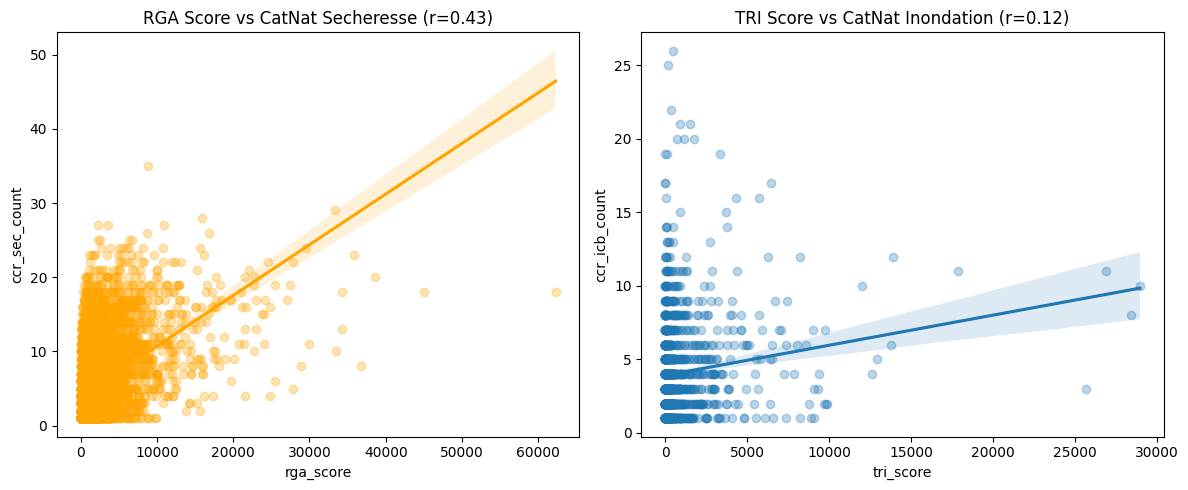

In [9]:
# Catnat correlations analysis

MIN_HOUSES = 100
MAX_HOUSES = 1000000
CCR_YEAR_FROM = 2000
CCR_CATNAT_RECO = False
CORR_METHOD = 'spearman'
CATNAT_CODES = ['SEC',  'ICB'] #'IRN',

# Load the flat + ccr datasets
df_flat = pd.read_parquet('../csv/risques_communes_flat.parquet')
ccr_details = pd.read_parquet('../csv_large/ccr_details.parquet')

# We add the CCR data
df_flat = fetch_catnat_data(ccr_details=ccr_details, catnat_codes=CATNAT_CODES, ccr_from_year=CCR_YEAR_FROM, reco_mask=CCR_CATNAT_RECO)

# We run RGA and inondations corelations
run_correlations()



In [92]:
df_flat[['total_maisons', 'rga_score', 'catnat_sec_count', 'tri_score', 'catnat_inond_count']].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])

,total_maisons,rga_score,catnat_sec_count,tri_score,catnat_inond_count
count,14085.000000,14085.000000,14085.000000,14085.000000,14085.000000
mean,744.497409,1203.620696,3.356905,90.594533,5.154917
std,1444.266314,2475.723011,3.113753,744.319967,3.514646
min,5.000000,0.000000,1.000000,0.000000,1.000000
5%,57.000000,30.000000,1.000000,0.000000,1.000000
25%,151.000000,147.500000,1.000000,0.000000,3.000000
50%,321.000000,414.000000,2.000000,0.000000,4.000000
75%,755.000000,1157.500000,4.000000,0.000000,7.000000
95%,2723.000000,4983.300000,9.000000,227.600000,12.000000
max,38130.000000,62255.500000,50.000000,28972.000000,53.000000


In [ ]:
df_flat.tri_score

In [46]:
df_flat.columns

Index(['code_commune_insee', 'total_maisons', 'rga_1945_1975_faible',
       'rga_1945_1975_moyen', 'rga_1945_1975_nul', 'rga_1945_1975_fort',
       'rga_1976_2020_faible', 'rga_1976_2020_moyen', 'rga_1976_2020_nul',
       'rga_1976_2020_fort', 'rga_post2020_faible', 'rga_post2020_moyen',
       'rga_post2020_nul', 'rga_post2020_fort', 'rga_pre1945_faible',
       'rga_pre1945_moyen', 'rga_pre1945_nul', 'rga_pre1945_fort',
       'rga_unk_faible', 'rga_unk_moyen', 'rga_unk_nul', 'rga_unk_fort',
       'tri_nul_nul', 'tri_t01_faible', 'tri_t01_fort', 'tri_t01_moyen',
       'tri_t02_faible', 'tri_t02_fort', 'tri_t02_moyen', 'tri_t03_faible',
       'tri_t03_fort', 'tri_t03_moyen', 'catnat_sec_count',
       'catnat_inond_count', 'total_maisons_post45', 'rga_score', 'tri_score'],
      dtype='str')

In [97]:
df_tri.sort_values(by='catnat_inond_count', ascending=False).head().transpose()

,630,583,7774,4975,597
code_commune_insee,06088,06004,49261,33069,06027
total_maisons,10552,6906,3950,5456,4380
rga_1945_1975_faible,0,0,1,0,0
rga_1945_1975_moyen,2010,1361,385,1066,898
rga_1945_1975_nul,23,60,7,2,4
rga_1945_1975_fort,142,525,41,140,317
rga_1976_2020_faible,0,0,12,0,0
rga_1976_2020_moyen,3466,1521,1245,1038,1451
rga_1976_2020_nul,34,76,12,9,8
rga_1976_2020_fort,96,1044,132,185,537
